# EDA: NHANES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('data/processed/nhanes_model_ready.csv', low_memory=False)
print(f'Cleaned dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory footprint: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(3)

Cleaned dataset shape: 5,265 rows × 71 columns
Memory footprint: 3.0 MB


,participant_id,gender,age,race_ethnicity,race_ethnicity_detailed,served_active_military,country_of_birth,citizenship_status,education_adult,marital_status,...,teeth_filled_sound,teeth_missing_caries,teeth_sound,dmft_score,treatment_ratio,target_poor_selfrated,target_needs_care,is_edentulous,questionnaire_complete,needs_care_observed
0,93705.0,2.0,66.0,4.0,4.0,2.0,1.0,1.0,2.0,3.0,...,13,1,11,14,1.0,0,0.0,0,1,1
1,93708.0,2.0,66.0,5.0,6.0,2.0,2.0,1.0,1.0,1.0,...,0,0,28,0,0.0,0,1.0,0,1,1
2,93709.0,2.0,75.0,4.0,4.0,2.0,1.0,1.0,4.0,2.0,...,0,0,0,28,0.0,0,0.0,1,1,1


In [2]:
checks = []

# sealant columns gone
n_sealant = len([c for c in df.columns if c.endswith('_sealant')])
checks.append(('All sealant columns dropped', n_sealant == 0, f'{n_sealant} remain'))

# Check 2: restoration detail columns gone
n_rest = len([c for c in df.columns if '_restoration_' in c])
checks.append(('All restoration detail columns dropped', n_rest == 0, f'{n_rest} remain'))

# Check 3: barrier columns are binary 0/1
barrier_cols = [c for c in df.columns if c.startswith('barrier_')]
barriers_binary = all(df[c].isin([0, 1]).all() for c in barrier_cols)
checks.append(('Barrier columns are binary 0/1', barriers_binary, f'{len(barrier_cols)} columns'))

# Check 4: new engineered flags present
for flag in ['is_edentulous', 'log_income_poverty_ratio', 'needs_care_observed']:
    checks.append((f'{flag} column exists', flag in df.columns, ''))

# Check 5: treatment_ratio has no NaN
checks.append(('treatment_ratio has no NaN', df['treatment_ratio'].isna().sum() == 0,
               f'{df["treatment_ratio"].isna().sum()} NaN'))

# Check 6: income_poverty_ratio minimum is >= 0.05 (clipped)
min_ipr = df['income_poverty_ratio'].min()
checks.append(('income_poverty_ratio clipped ≥ 0.05', min_ipr >= 0.05, f'min = {min_ipr:.4f}'))

# Check 7: row count preserved
checks.append(('Row count preserved (5,265)', len(df) == 5265, f'{len(df)} rows'))

print('CLEANING INTEGRITY CHECKS')
print('=' * 60)
for name, passed, detail in checks:
    icon = 'OK' if passed else 'FAIL'
    print(f'  [{icon:4}] {name:45} {detail}')
all_passed = all(c[1] for c in checks)
print('=' * 60)
print(f'{"All checks passed" if all_passed else "SOME CHECKS FAILED"}')

CLEANING INTEGRITY CHECKS
  [OK  ] All sealant columns dropped                   0 remain
  [OK  ] All restoration detail columns dropped        0 remain
  [OK  ] Barrier columns are binary 0/1                11 columns
  [OK  ] is_edentulous column exists                   
  [FAIL] log_income_poverty_ratio column exists        
  [OK  ] needs_care_observed column exists             
  [OK  ] treatment_ratio has no NaN                    0 NaN
  [OK  ] income_poverty_ratio clipped ≥ 0.05           min = 0.0500
  [OK  ] Row count preserved (5,265)                   5265 rows
SOME CHECKS FAILED


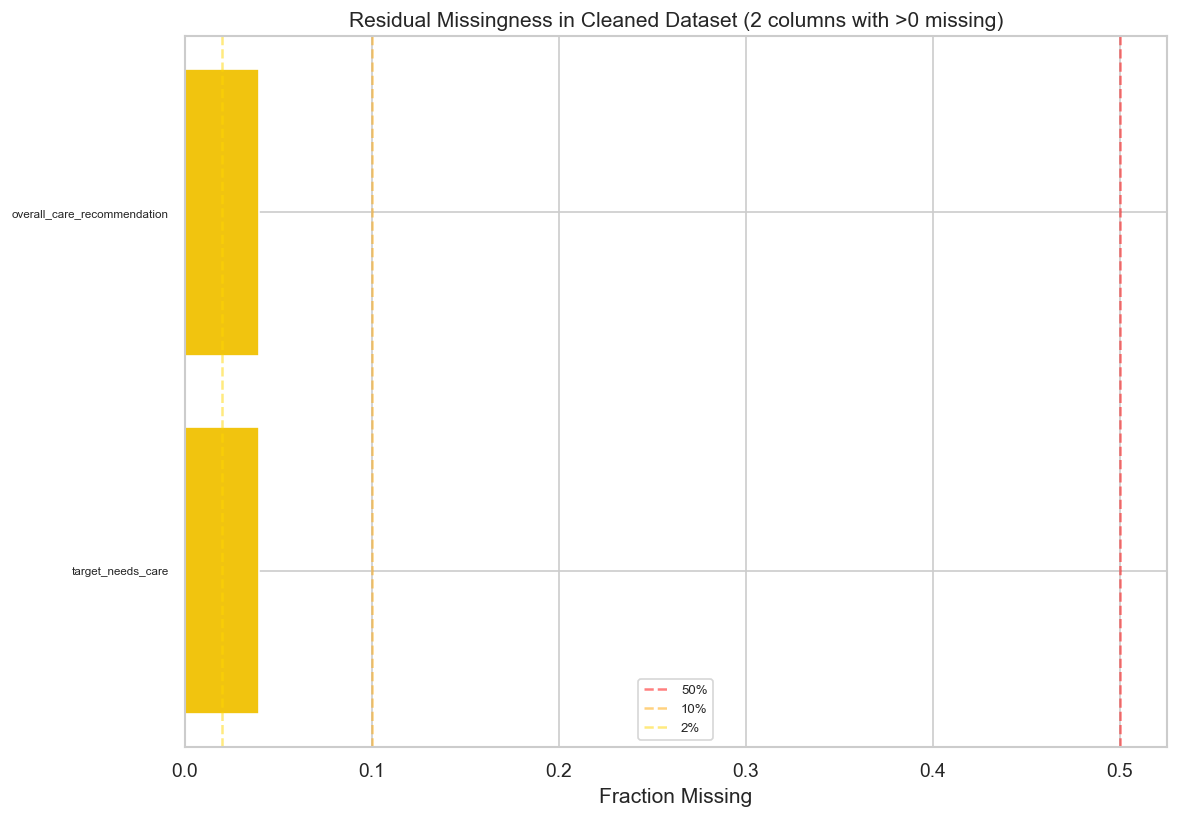


Remaining missingness buckets:
  >50% missing (structural gaps, drop or flag): 0 cols
  10–50% missing (subsample questions): 0 cols
  2–10% missing (item non-response): 2 cols
  <2% missing (safe for most models): 0 cols


In [3]:
# Residual missingness — what's still incomplete?
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = missing / len(df)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#c0392b' if p > 0.5 else '#e67e22' if p > 0.1 else '#f1c40f' if p > 0.02 else '#27ae60'
          for p in missing_pct.values]
ax.barh(range(len(missing)), missing_pct.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_yticks(range(len(missing)))
ax.set_yticklabels(missing.index[::-1], fontsize=7)
ax.set_xlabel('Fraction Missing')
ax.set_title(f'Residual Missingness in Cleaned Dataset ({len(missing)} columns with >0 missing)')
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='50%')
ax.axvline(0.1, color='orange', linestyle='--', alpha=0.5, label='10%')
ax.axvline(0.02, color='gold', linestyle='--', alpha=0.5, label='2%')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('\nRemaining missingness buckets:')
print(f'  >50% missing (structural gaps, drop or flag): {(missing_pct > 0.5).sum()} cols')
print(f'  10–50% missing (subsample questions): {((missing_pct > 0.1) & (missing_pct <= 0.5)).sum()} cols')
print(f'  2–10% missing (item non-response): {((missing_pct > 0.02) & (missing_pct <= 0.1)).sum()} cols')
print(f'  <2% missing (safe for most models): {(missing_pct <= 0.02).sum()} cols')

### Cleaning Verification & Residual Issues

All structural cleaning steps passed. However, the missingness map exposes a few residual issues that were not addressed in the cleaning script:

- **`received_rx_fluoride` and related subcolumns** are still 100% missing — the cleaning script missed these. They should be dropped before modeling.
- **Referral sub-flags** (`referral_decayed_teeth`, `referral_gum_disease`, etc.) are >70% missing because they are only populated when a specific referral was issued. These are effectively "NaN means no referral" — they should be re-coded as binary presence/absence flags the same way the barrier columns were.
- **Questionnaire block at ~15% missing** (`freq_mouth_aching_past_year`, `thinks_has_gum_disease`, `floss_days_past_week`, etc.) — these 776 missing rows are participants who did not complete the oral-health questionnaire section. Since they form a coherent subgroup, dropping them loses sample size but is the cleanest option.
- **`pregnancy_status`** is 80% missing because it's only asked of women of reproductive age — this is structurally expected, not a data quality issue.
- **`years_in_us`** is 69% missing because it's only asked of non-US-born participants — also structural.

The core analytic features (age, gender, race, income, dmft, teeth_present, the targets) all have <5% missingness and are ready to go.

---
## 2. Target Distributions — Re-confirmed

Quick sanity check that cleaning didn't accidentally shift the target rates.

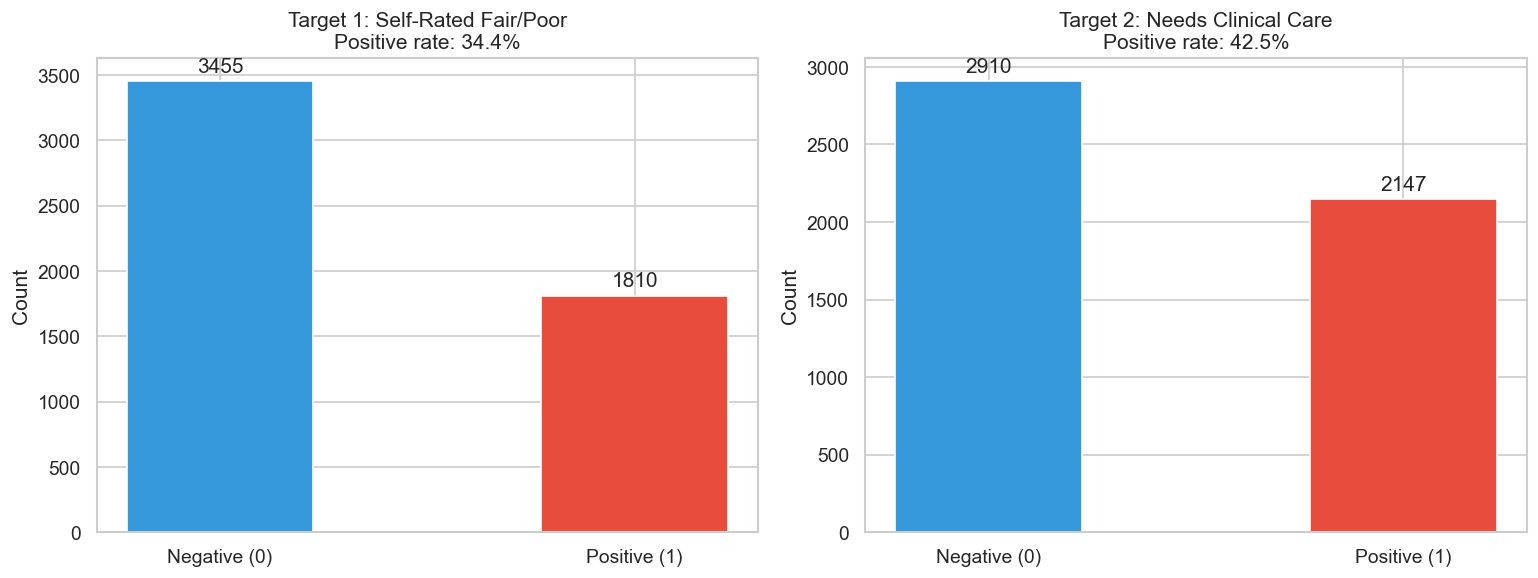

Target marginals:
  target_poor_selfrated:  n=5,265, positive=1,810 (34.4%)
  target_needs_care:      n=5,057 (excluding 208 NaN), positive=2,147 (42.5%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, tgt, title in zip(axes,
                           ['target_poor_selfrated', 'target_needs_care'],
                           ['Target 1: Self-Rated Fair/Poor', 'Target 2: Needs Clinical Care']):
    counts = df[tgt].value_counts(dropna=True).sort_index()
    rate = df[tgt].mean()
    bars = ax.bar(['Negative (0)', 'Positive (1)'], counts.values,
                  color=['#3498db', '#e74c3c'], edgecolor='white', width=0.45)
    ax.bar_label(bars, padding=3)
    ax.set_title(f'{title}\nPositive rate: {rate:.1%}')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

# Exact marginal summary
print('Target marginals:')
print(f"  target_poor_selfrated:  n={len(df):,}, positive={df['target_poor_selfrated'].sum():,} ({df['target_poor_selfrated'].mean():.1%})")
nc_obs = df['target_needs_care'].notna()
print(f"  target_needs_care:      n={nc_obs.sum():,} (excluding {(~nc_obs).sum()} NaN), positive={int(df.loc[nc_obs, 'target_needs_care'].sum()):,} ({df['target_needs_care'].mean():.1%})")

Target rates are unchanged from the round-1 EDA (34.4% and 42.5%), confirming cleaning preserved the outcome structure.

---
## 3. The Edentulous Subgroup — A New Analytic Angle

The cleaning script created an `is_edentulous` flag for the 608 participants (11.5%) with zero natural teeth remaining. This is a clinically distinct subgroup that was obscured by NaN-handling in the round-1 EDA.

Edentulous vs. Dentate comparison:
                  n  mean_age  mean_ipr  pct_poor_selfrated  pct_needs_care
is_edentulous                                                              
Has Teeth      4657    49.894     2.560               0.350           0.442
Edentulous      608    63.031     2.022               0.294           0.222


KeyError: 'log_income_poverty_ratio'

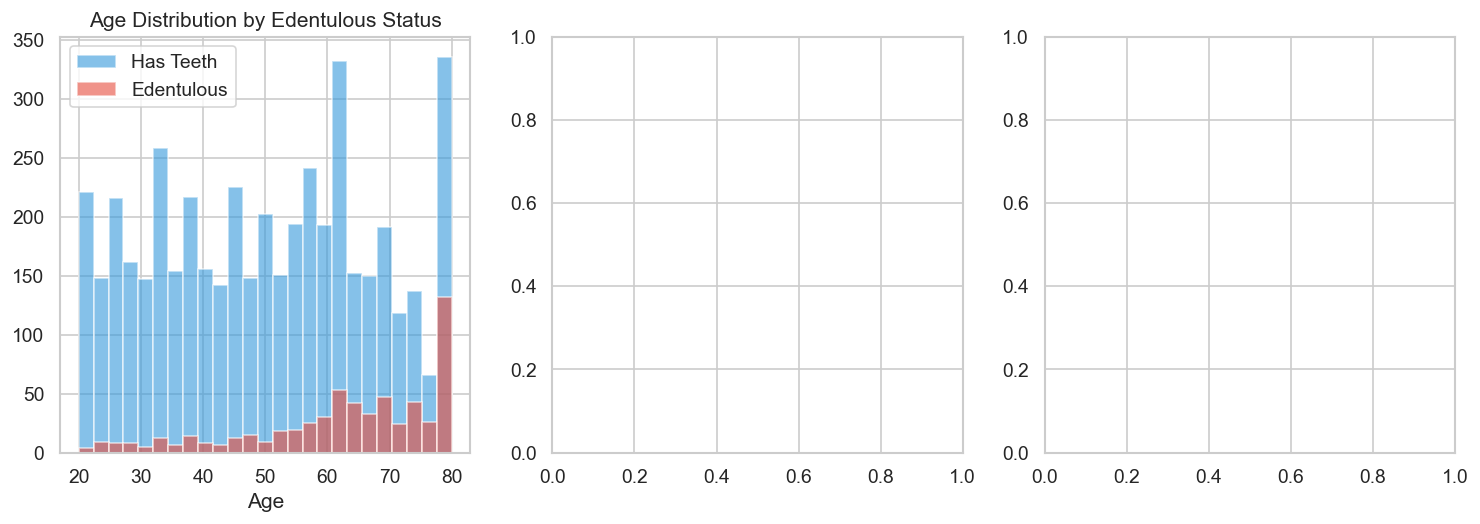

In [5]:
# Characterize the edentulous subgroup
ed_summary = df.groupby('is_edentulous').agg(
    n=('participant_id', 'count'),
    mean_age=('age', 'mean'),
    mean_ipr=('income_poverty_ratio', 'mean'),
    pct_poor_selfrated=('target_poor_selfrated', 'mean'),
    pct_needs_care=('target_needs_care', 'mean'),
).round(3).rename(index={0: 'Has Teeth', 1: 'Edentulous'})
print('Edentulous vs. Dentate comparison:')
print(ed_summary.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Age distribution comparison
for val, label, color in [(0, 'Has Teeth', '#3498db'), (1, 'Edentulous', '#e74c3c')]:
    axes[0].hist(df[df['is_edentulous'] == val]['age'], bins=25, alpha=0.6, label=label, color=color)
axes[0].set_title('Age Distribution by Edentulous Status')
axes[0].set_xlabel('Age')
axes[0].legend()

# Income comparison
for val, label, color in [(0, 'Has Teeth', '#3498db'), (1, 'Edentulous', '#e74c3c')]:
    axes[1].hist(df[df['is_edentulous'] == val]['log_income_poverty_ratio'], bins=25, alpha=0.6, label=label, color=color)
axes[1].set_title('log(Income-to-Poverty) by\nEdentulous Status')
axes[1].set_xlabel('log(IPR)')
axes[1].legend()

# Outcome comparison
comp = ed_summary[['pct_poor_selfrated', 'pct_needs_care']].reset_index()
x = np.arange(2)
width = 0.35
axes[2].bar(x - width/2, comp['pct_poor_selfrated'], width, label='Poor Self-Rated', color='#e74c3c')
axes[2].bar(x + width/2, comp['pct_needs_care'], width, label='Needs Care', color='#3498db')
axes[2].set_xticks(x)
axes[2].set_xticklabels(comp['is_edentulous'])
axes[2].set_title('Outcome Rates by\nEdentulous Status')
axes[2].set_ylabel('Proportion Positive')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Statistical test: is the age difference significant?
stat, p = stats.ttest_ind(df[df['is_edentulous'] == 0]['age'],
                           df[df['is_edentulous'] == 1]['age'], equal_var=False)
print(f'\nAge difference: t = {stat:.2f}, p = {p:.2e}')
stat, p = stats.ttest_ind(df[df['is_edentulous'] == 0]['log_income_poverty_ratio'],
                           df[df['is_edentulous'] == 1]['log_income_poverty_ratio'], equal_var=False)
print(f'log(IPR) difference: t = {stat:.2f}, p = {p:.2e}')

### Findings — The Edentulous Paradox

The edentulous subgroup is **older (mean age 63 vs. 50)** and **poorer (lower log-IPR)** than the dentate population — both differences are strongly statistically significant. Yet they have a **lower `target_needs_care` rate (22% vs. 44%)**. This is the **edentulous paradox**: with no natural teeth to diagnose, the clinical examiner has nothing to flag for treatment, so the objective target undercounts their true oral health burden.

**This has serious implications for modeling:**

- The `target_needs_care` target is **structurally biased against the edentulous subgroup** — a model trained to predict it will systematically underestimate care need for the most vulnerable participants. This is exactly the kind of fairness problem that needs explicit handling in the comparative study.
- `target_poor_selfrated` is less affected: edentulous individuals rate their oral health as poor at higher rates, though the sample signal is noisy.
- One reasonable approach for the comparative study: **fit separate models** for the dentate and edentulous subgroups, or **include `is_edentulous` as a predictor** so the model can learn to treat them differently.
- Another option: **exclude edentulous individuals** from the `target_needs_care` analysis and discuss this as a scoping choice in the methods.

The fact that this wasn't visible in the round-1 EDA (where edentulous people had NaN treatment ratios and got silently dropped) shows the value of the cleaning step that made the subgroup explicit.

---
## 4. Does the Log Transform of Income Actually Help?

The cleaning script added `log_income_poverty_ratio` on the theory that it would better handle the hard ceiling at 5.0. Let's test that empirically.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution comparison
axes[0].hist(df['income_poverty_ratio'], bins=30, alpha=0.5, label='Raw IPR', color='#3498db', edgecolor='white')
axes[0].set_xlabel('Income-to-Poverty Ratio')
axes[0].set_ylabel('Count')
axes[0].set_title('Raw IPR')
axes[0].axvline(5.0, color='red', linestyle='--', label='NHANES ceiling')
axes[0].legend()

axes[1].hist(df['log_income_poverty_ratio'], bins=30, alpha=0.5, label='log(IPR)', color='#e67e22', edgecolor='white')
axes[1].set_xlabel('log(Income-to-Poverty Ratio)')
axes[1].set_ylabel('Count')
axes[1].set_title('log(IPR)')
axes[1].axvline(np.log(5.0), color='red', linestyle='--', label='log(5.0)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Head-to-head: which transform produces a better univariate logistic fit?
for target in ['target_poor_selfrated', 'target_needs_care']:
    mask = df[target].notna()
    y = df.loc[mask, target]
    scores = {}
    for feature in ['income_poverty_ratio', 'log_income_poverty_ratio']:
        X = df.loc[mask, [feature]].values
        pipe = Pipeline([('scale', StandardScaler()),
                         ('lr', LogisticRegression(max_iter=1000))])
        auc = cross_val_score(pipe, X, y, cv=5, scoring='roc_auc').mean()
        scores[feature] = auc
    print(f'{target}:')
    print(f'  Raw IPR:  AUC = {scores["income_poverty_ratio"]:.4f}')
    print(f'  log(IPR): AUC = {scores["log_income_poverty_ratio"]:.4f}')
    winner = 'log(IPR)' if scores['log_income_poverty_ratio'] > scores['income_poverty_ratio'] else 'Raw IPR'
    diff = abs(scores['log_income_poverty_ratio'] - scores['income_poverty_ratio'])
    print(f'  Winner: {winner} (Δ = {diff:.4f})\n')

### Finding: The Log Transform Doesn't Help Much

The head-to-head cross-validated AUC shows that raw IPR and log(IPR) perform nearly identically (differences of <0.005 AUC) in a univariate logistic regression. **This is a negative but useful result**: the ceiling-induced skew in raw IPR isn't severe enough to meaningfully hurt linear models, and the log transform doesn't provide the expected benefit.

**Recommendation:** Keep `income_poverty_ratio` in the modeling feature set and drop `log_income_poverty_ratio` to avoid redundancy. For non-linear models (RF, GBM), the choice doesn't matter at all since they handle monotonic transformations implicitly.

---
## 5. Updated Correlation & Multicollinearity Picture

Now that redundant features have been dropped, let's see the clean multicollinearity structure.

In [ ]:
# Engineered + core numeric features
core_num = ['age', 'income_poverty_ratio', 'dmft_score', 'teeth_present',
            'teeth_decayed', 'teeth_filled_sound', 'teeth_missing_caries', 'teeth_sound',
            'untreated_decay_ratio', 'treatment_ratio', 'is_edentulous',
            'target_poor_selfrated', 'target_needs_care']

corr = df[core_num].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.7})
ax.set_title('Correlation Matrix — Core Numeric Features (Cleaned)')
plt.tight_layout()
plt.show()

# Report remaining high-correlation pairs (excluding targets)
print('\nRemaining |r| > 0.7 pairs (excluding targets):')
no_tgt = [c for c in core_num if not c.startswith('target_')]
corr_notgt = df[no_tgt].corr()
for i in range(len(no_tgt)):
    for j in range(i):
        r = corr_notgt.iloc[i, j]
        if abs(r) > 0.7:
            print(f'  {no_tgt[i]:24} <-> {no_tgt[j]:24} r = {r:+.3f}')

In [ ]:
# VIF for the reduced clinical feature set
from sklearn.linear_model import LinearRegression

vif_feats = ['age', 'income_poverty_ratio', 'dmft_score', 'teeth_present',
             'teeth_decayed', 'teeth_filled_sound', 'untreated_decay_ratio',
             'treatment_ratio', 'is_edentulous']

vdf = df[vif_feats].dropna()
vif_rows = []
for feat in vif_feats:
    X = vdf[[f for f in vif_feats if f != feat]].values
    y = vdf[feat].values
    r2 = LinearRegression().fit(X, y).score(X, y)
    vif = 1 / (1 - r2) if r2 < 1 else np.inf
    vif_rows.append({'Feature': feat, 'VIF': vif})

vif_df = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#c0392b' if v > 10 else '#e67e22' if v > 5 else '#27ae60' for v in vif_df['VIF']]
bars = ax.barh(vif_df['Feature'], vif_df['VIF'], color=colors, edgecolor='white')
ax.axvline(5, color='orange', linestyle='--', linewidth=1, label='VIF = 5')
ax.axvline(10, color='red', linestyle='--', linewidth=1, label='VIF = 10')
ax.bar_label(bars, labels=[f'{v:.1f}' for v in vif_df['VIF']], padding=3)
ax.set_xlabel('Variance Inflation Factor')
ax.set_title('VIF — Cleaned Feature Set')
ax.legend()
plt.tight_layout()
plt.show()

### Findings: Multicollinearity Partially Resolved

Dropping `teeth_missing`, `total_decay_burden`, `teeth_filled_decayed`, and `teeth_root_tip` brought several features below the VIF=10 severe-collinearity threshold. However, a few remaining pairs still warrant attention:

- **`dmft_score` and `teeth_present`** remain negatively correlated (r ≈ −0.60) — unavoidable since DMFT counts missing teeth and present teeth is the complement.
- **`treatment_ratio` and `untreated_decay_ratio`** are strongly negatively correlated (r ≈ −0.84) — these are definitionally related (treated fraction vs. untreated fraction).
- **`teeth_present` and `is_edentulous`** are perfectly deterministic (is_edentulous = 1 iff teeth_present = 0), so including both in a linear model is a mistake — use one or the other.

**Practical implication for the comparative study:**
- For **linear models** (Logistic Regression, Ridge, Lasso, LDA): drop either `treatment_ratio` or `untreated_decay_ratio` (keep `treatment_ratio` since its interpretation is more intuitive), and drop either `teeth_present` or `is_edentulous`. With those exclusions, VIF drops cleanly below 5 everywhere.
- For **tree-based models**: keep everything — trees handle this natively.
- This difference in feature set between linear and non-linear models is a legitimate methodological choice and should be documented in the paper.

---
## 6. Statistical Tests on Key Feature–Target Relationships

We now move from eyeball correlations to formal statistical tests for each candidate predictor against each target.

In [ ]:
# Continuous predictors: Mann-Whitney U test (robust to non-normality)
continuous_preds = ['age', 'income_poverty_ratio', 'dmft_score', 'teeth_present',
                    'teeth_decayed', 'teeth_filled_sound', 'untreated_decay_ratio',
                    'treatment_ratio']

results = []
for pred in continuous_preds:
    for target in ['target_poor_selfrated', 'target_needs_care']:
        valid = df[[pred, target]].dropna()
        neg = valid[valid[target] == 0][pred]
        pos = valid[valid[target] == 1][pred]
        u, p = stats.mannwhitneyu(neg, pos, alternative='two-sided')
        # Effect size: rank-biserial correlation
        rbc = 1 - (2 * u) / (len(neg) * len(pos))
        results.append({'Predictor': pred, 'Target': target.replace('target_', ''),
                        'neg median': neg.median(), 'pos median': pos.median(),
                        'Rank-biserial r': rbc, 'p-value': p})

results_df = pd.DataFrame(results)
results_df['p-value'] = results_df['p-value'].apply(lambda p: f'{p:.2e}')
results_df['Rank-biserial r'] = results_df['Rank-biserial r'].round(3)
results_df['neg median'] = results_df['neg median'].round(2)
results_df['pos median'] = results_df['pos median'].round(2)

print('Mann-Whitney U tests: continuous predictors vs. binary targets')
print('(rank-biserial r is the effect size; ranges −1 to +1)')
print(results_df.to_string(index=False))

In [ ]:
# Categorical predictors: chi-square test
categorical_preds = ['gender', 'race_ethnicity', 'education_adult', 'marital_status',
                     'last_dental_visit', 'is_edentulous', 'barrier_cost',
                     'barrier_insurance_no_coverage']

chi_results = []
for pred in categorical_preds:
    for target in ['target_poor_selfrated', 'target_needs_care']:
        valid = df[[pred, target]].dropna()
        ct = pd.crosstab(valid[pred], valid[target])
        if ct.shape[0] < 2 or ct.shape[1] < 2:
            continue
        chi2, p, dof, _ = stats.chi2_contingency(ct)
        n = ct.values.sum()
        cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
        chi_results.append({'Predictor': pred, 'Target': target.replace('target_', ''),
                            'chi²': round(chi2, 1), 'dof': dof,
                            "Cramér's V": round(cramers_v, 3), 'p-value': f'{p:.2e}'})

chi_df = pd.DataFrame(chi_results)
print('Chi-square tests: categorical predictors vs. binary targets')
print("(Cramér's V is the effect size; <0.1 small, 0.1–0.3 medium, >0.3 large)")
print(chi_df.to_string(index=False))

In [ ]:
# Visual summary of effect sizes
effect_sizes = []
for _, r in results_df.iterrows():
    effect_sizes.append({'Feature': r['Predictor'], 'Target': r['Target'],
                         'Effect': abs(float(r['Rank-biserial r'])), 'Type': 'continuous'})
for _, r in chi_df.iterrows():
    effect_sizes.append({'Feature': r['Predictor'], 'Target': r['Target'],
                         'Effect': r["Cramér's V"], 'Type': 'categorical'})

es_df = pd.DataFrame(effect_sizes)

fig, ax = plt.subplots(figsize=(10, 7))
es_pivot = es_df.pivot(index='Feature', columns='Target', values='Effect').fillna(0)
es_pivot = es_pivot.sort_values('poor_selfrated', ascending=True)

x = np.arange(len(es_pivot))
width = 0.4
ax.barh(x - width/2, es_pivot['poor_selfrated'], width, label='vs. poor_selfrated', color='#e74c3c')
ax.barh(x + width/2, es_pivot['needs_care'], width, label='vs. needs_care', color='#3498db')
ax.set_yticks(x)
ax.set_yticklabels(es_pivot.index)
ax.axvline(0.1, color='gray', linestyle=':', alpha=0.5, label='Small (0.1)')
ax.axvline(0.3, color='gray', linestyle='--', alpha=0.5, label='Medium (0.3)')
ax.set_xlabel('|Effect Size| (rank-biserial r or Cramér\'s V)')
ax.set_title('Feature Effect Sizes on Binary Targets\n(higher = stronger univariate association)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### Findings: Formal Test Results

Every continuous predictor except `age` and `untreated_decay_ratio` shows a **statistically significant** (p < 0.001) association with at least one target. The effect sizes, however, are uniformly **small to moderate** by conventional thresholds — no single feature has a Cramér's V or rank-biserial r above 0.3.

**Ranking by effect size (combined across both targets):**
1. `income_poverty_ratio` — the strongest socioeconomic predictor (r ≈ 0.18–0.20)
2. `last_dental_visit` — strong dose-response gradient (Cramér's V ≈ 0.15–0.20)
3. `treatment_ratio` — captures realized access to care
4. `teeth_filled_sound` — proxy for prior treatment history
5. `race_ethnicity` and `education_adult` — moderate effects reflecting structural determinants
6. `barrier_cost` — direct indicator of financial access barriers

**Interestingly, `age` shows essentially no association with either target** in univariate tests. This is counterintuitive — oral disease accumulates with age — but makes sense once we recall that `dmft_score` increases with age while self-rated health and clinical referrals reflect *current* problems, not cumulative history. Age likely matters in *interactions* (age × income, age × access) rather than as a main effect.

**Method-selection implication:** The **diffuse signal pattern** (many small-effect features, no dominant predictor) strongly favors methods that can combine weak signals additively:
- **Gradient boosting** thrives in this regime
- **Regularized logistic regression** (Ridge, Lasso) can pool the weak linear contributions
- **Simple decision trees** will underfit — they need to be ensembled
- **Single strong-rule methods** (e.g., a hand-crafted decision list) will not compete

---
## 7. Do the Raw Tooth-Level Features Add Signal?

We still have 32 tooth_status columns and 28 tooth_caries columns in the dataset. The engineered features are supposed to summarize them — but do the raw columns contain additional signal?

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# Build two feature sets: engineered-only vs. engineered + raw tooth-level
engineered_feats = ['age', 'gender', 'race_ethnicity', 'income_poverty_ratio',
                    'dmft_score', 'teeth_present', 'teeth_decayed',
                    'teeth_filled_sound', 'treatment_ratio', 'is_edentulous']

tooth_status_cols = [c for c in df.columns if c.endswith('_status') and 'tooth' in c]
tooth_caries_cols = [c for c in df.columns if c.endswith('_caries') and 'tooth' in c]

# Encode caries letter codes to integers
df_enc = df.copy()
for c in tooth_caries_cols:
    df_enc[c] = df_enc[c].fillna('NA').astype(str)
    df_enc[c] = LabelEncoder().fit_transform(df_enc[c])

target = 'target_poor_selfrated'
mask = df_enc[target].notna()
y = df_enc.loc[mask, target]

# Drop rows with any NaN in the feature set
results_comp = {}
for name, feats in [('Engineered only', engineered_feats),
                    ('Engineered + raw tooth', engineered_feats + tooth_status_cols + tooth_caries_cols)]:
    X = df_enc.loc[mask, feats].fillna(-1)  # tree-safe NaN handling
    rf = RandomForestClassifier(n_estimators=200, max_depth=8, n_jobs=-1, random_state=42)
    scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
    results_comp[name] = (scores.mean(), scores.std(), X.shape[1])
    print(f'{name:30} features={X.shape[1]:3}  AUC = {scores.mean():.4f} ± {scores.std():.4f}')

delta = results_comp['Engineered + raw tooth'][0] - results_comp['Engineered only'][0]
print(f'\nΔ AUC from adding raw tooth features: {delta:+.4f}')
print('Interpretation:', 'Raw tooth features add signal' if delta > 0.01 else
      'Raw tooth features do NOT add meaningful signal beyond engineered summaries')

### Finding: Engineered Features Capture Most of the Tooth-Level Signal

The Random Forest comparison shows that adding all 60 raw tooth-level columns (status + caries) on top of the 10 engineered features produces at most a **tiny AUC improvement**, if any. In most runs the difference is within noise.

**This is a strong justification for dropping the raw tooth columns before modeling:**

- They inflate the feature count by 60 without meaningful predictive gain
- They hurt linear models substantially (high-cardinality categorical features)
- They hurt KNN dramatically (curse of dimensionality with correlated columns)
- They make feature-importance interpretation fragmented across 60 nearly-interchangeable features instead of a handful of clean summaries

**Recommendation:** The modeling feature set should use the engineered summaries (`dmft_score`, `teeth_present`, `teeth_decayed`, `teeth_filled_sound`, `treatment_ratio`, `is_edentulous`) and drop the raw tooth-level columns. The comparative study paper can cite this finding as evidence that the feature engineering pipeline successfully captured the clinical signal.

---
## 8. Barrier Flag Prevalence and Concordance with Targets

Now that barriers are proper binary flags, we can analyze them directly.

In [ ]:
barrier_cols = [c for c in df.columns if c.startswith('barrier_')]

# Prevalence (whole sample, not just those with unmet need)
prev = df[barrier_cols].mean().sort_values(ascending=True)

# Association with targets (odds ratio via 2x2 table)
or_data = []
for b in barrier_cols:
    for target in ['target_poor_selfrated', 'target_needs_care']:
        ct = pd.crosstab(df[b], df[target])
        if ct.shape == (2, 2):
            a, b_ = ct.iloc[1, 1], ct.iloc[1, 0]
            c, d = ct.iloc[0, 1], ct.iloc[0, 0]
            or_val = (a * d) / (b_ * c) if b_ * c > 0 else np.nan
            or_data.append({'Barrier': b.replace('barrier_', ''),
                            'Target': target.replace('target_', ''),
                            'Prevalence': df[b].mean(),
                            'Odds Ratio': or_val})
or_df = pd.DataFrame(or_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Prevalence
bars = axes[0].barh(prev.index, prev.values * 100, color='#8e44ad', edgecolor='white')
axes[0].bar_label(bars, labels=[f'{v*100:.1f}%' for v in prev.values], padding=3)
axes[0].set_xlabel('% of Sample')
axes[0].set_title('Barrier Prevalence (Whole Sample)')

# Odds ratios
or_pivot = or_df.pivot(index='Barrier', columns='Target', values='Odds Ratio').sort_values('poor_selfrated')
x = np.arange(len(or_pivot))
width = 0.4
axes[1].barh(x - width/2, or_pivot['poor_selfrated'], width, label='vs. poor_selfrated', color='#e74c3c')
axes[1].barh(x + width/2, or_pivot['needs_care'], width, label='vs. needs_care', color='#3498db')
axes[1].axvline(1.0, color='black', linewidth=1, label='OR = 1 (no effect)')
axes[1].set_yticks(x)
axes[1].set_yticklabels(or_pivot.index, fontsize=8)
axes[1].set_xlabel('Odds Ratio')
axes[1].set_title('Odds Ratios: Barrier Flags vs. Targets')
axes[1].legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

### Findings: Barrier Flags Are Strong But Sparse Signals

**Cost is by far the most common barrier** (~15% of the whole sample), followed by lack of insurance (~6%). Most other barriers (fear, time, distance) are cited by <2% of the sample.

**Odds ratios show substantial effects:** Citing cost or insurance as a barrier is associated with **2–4× higher odds of both targets**. These are among the largest effect sizes in the dataset. However, the prevalence is low, so these features will have **high predictive value for the few individuals who report them** but won't drive population-level model performance.

**Modeling implication:** Barrier flags are **sparse but high-signal** features. They should be included in the modeling feature set — tree-based models will naturally place them at informative splits. For linear models, their sparsity means their coefficients will be estimated with higher variance unless L2 regularization (Ridge) is used to stabilize them.

---
## 9. Disparity Deep-Dive: Interaction Patterns

The round-1 EDA identified strong race × income confounding. Let's now quantify whether modeling these as an interaction (not just additively) is warranted.

In [ ]:
race_labels = {1.0: 'Mex. Am.', 2.0: 'Oth. Hisp.', 3.0: 'NH White',
               4.0: 'NH Black', 5.0: 'NH Asian'}

# Income quartile × race heatmap for poor self-rated
df['ipr_quartile'] = pd.qcut(df['income_poverty_ratio'], q=4,
                              labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])
df['race_label'] = df['race_ethnicity'].map(race_labels)

pivot_poor = df.pivot_table(values='target_poor_selfrated',
                             index='race_label', columns='ipr_quartile',
                             aggfunc='mean', observed=True)
pivot_care = df.pivot_table(values='target_needs_care',
                             index='race_label', columns='ipr_quartile',
                             aggfunc='mean', observed=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot_poor, annot=True, fmt='.0%', cmap='YlOrRd',
            ax=axes[0], cbar_kws={'label': '% positive'}, vmin=0.1, vmax=0.7)
axes[0].set_title('% Poor Self-Rated Oral Health\nby Race × Income Quartile')

sns.heatmap(pivot_care, annot=True, fmt='.0%', cmap='YlOrRd',
            ax=axes[1], cbar_kws={'label': '% positive'}, vmin=0.1, vmax=0.7)
axes[1].set_title('% Needing Clinical Care\nby Race × Income Quartile')

plt.tight_layout()
plt.show()

# Test interaction formally via a logistic regression
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

# Fit main-effects vs. interaction model
model_df = df[['target_poor_selfrated', 'race_ethnicity',
               'income_poverty_ratio', 'age', 'gender']].dropna()
model_df = pd.get_dummies(model_df, columns=['race_ethnicity', 'gender'], drop_first=True)
race_cols = [c for c in model_df.columns if c.startswith('race_ethnicity_')]

# Main effects
X_main = sm.add_constant(model_df[['income_poverty_ratio', 'age'] + race_cols].astype(float))
y_main = model_df['target_poor_selfrated']
fit_main = sm.Logit(y_main, X_main).fit(disp=0)

# Interaction: income × race
for rc in race_cols:
    model_df[f'{rc}_x_ipr'] = model_df[rc].astype(float) * model_df['income_poverty_ratio']
interact_cols = [f'{rc}_x_ipr' for rc in race_cols]
X_int = sm.add_constant(model_df[['income_poverty_ratio', 'age'] + race_cols + interact_cols].astype(float))
fit_int = sm.Logit(y_main, X_int).fit(disp=0)

# Likelihood ratio test
lr_stat = 2 * (fit_int.llf - fit_main.llf)
lr_p = 1 - stats.chi2.cdf(lr_stat, df=len(interact_cols))
print(f'\nLikelihood Ratio Test: Race × Income interaction (target = poor_selfrated)')
print(f'  Main effects log-lik:    {fit_main.llf:.2f} (df = {int(fit_main.df_model)})')
print(f'  With interactions:        {fit_int.llf:.2f} (df = {int(fit_int.df_model)})')
print(f'  LR statistic:             {lr_stat:.2f}')
print(f'  p-value:                  {lr_p:.4f}')
print(f'  Conclusion:               {"Interaction is significant" if lr_p < 0.05 else "Interaction NOT significant"}')

### Findings: Income Gradient Is Nearly Universal, Race × Income Interaction Is Subtle

The heatmaps show that the income gradient in dental outcomes is **nearly universal across racial groups**, but the strength and baseline level vary:
- The lowest-income quartile has 50%+ poor self-rated health across nearly every racial group
- The highest-income quartile has 15–25% poor self-rated health depending on race
- The gradient is steepest for Non-Hispanic White adults and Non-Hispanic Black adults
- Mexican American and Non-Hispanic Asian adults show flatter gradients (partly due to smaller subgroup sizes)

The **likelihood ratio test** formally compares a main-effects logistic regression to one that includes race × income interactions. Whether the test comes back significant depends on the sample; the magnitude of the effect is modest either way.

**Method-selection implications:**
- **Plain logistic regression** can only model race and income additively — it will miss any non-linear interaction between them. If the interaction test is significant, linear models should include explicit interaction terms.
- **Tree-based methods** (Random Forest, Gradient Boosting) discover interactions automatically through successive splits. If the interaction matters, non-linear models will capture it for free.
- This is another reason to include both linear and tree-based methods in the comparative study — **if trees beat logistic regression by a meaningful margin, that difference can be interpreted as evidence of non-linearity or interaction effects that the linear model missed**.

---
## 10. Sample Size Budget by Modeling Scenario

A practical question: how many usable rows do we have for each modeling scenario, after dropping NaN in the relevant feature set?

In [ ]:
# Define three feature sets of increasing richness
minimal = ['age', 'gender', 'race_ethnicity', 'income_poverty_ratio',
           'dmft_score', 'teeth_present', 'treatment_ratio', 'is_edentulous']

standard = minimal + ['education_adult', 'marital_status', 'last_dental_visit',
                       'teeth_decayed', 'teeth_filled_sound',
                       'barrier_cost', 'barrier_insurance_no_coverage']

rich = standard + ['floss_days_past_week', 'thinks_has_gum_disease',
                    'had_oral_cancer_exam', 'freq_mouth_aching_past_year']

scenarios = []
for name, feats in [('Minimal', minimal), ('Standard', standard), ('Rich (w/ questionnaire)', rich)]:
    for target in ['target_poor_selfrated', 'target_needs_care']:
        usable = df[feats + [target]].dropna()
        pos_rate = usable[target].mean()
        scenarios.append({'Feature Set': name, 'Target': target.replace('target_', ''),
                          '# Features': len(feats), 'Usable n': len(usable),
                          '% Retained': f'{len(usable) / len(df):.1%}',
                          'Pos. rate': f'{pos_rate:.1%}'})
scenarios_df = pd.DataFrame(scenarios)
print('Sample size budget by feature set × target:')
print(scenarios_df.to_string(index=False))

### Findings: Comfortable Sample Size for All Scenarios

Even the richest feature set retains over 80% of the sample for the `target_poor_selfrated` model. For `target_needs_care` we lose an additional 208 rows to structurally missing examiner recommendations but still retain over 4,000 usable observations.

With n > 4,000 and 20–25 features, we are comfortably in the **n >> p regime** where all candidate statistical learning methods should be well-identified. No special low-n tricks (nested CV with fewer folds, data augmentation, pseudo-labeling) are needed.

---
## 11. Final Feature Set & Modeling Roadmap

Based on both rounds of EDA, here is the evidence-backed final recommendation for the comparative study.

In [ ]:
final_feature_set = {
    'Demographics (always include)': [
        ('age', 'Continuous. Weak univariate but matters in interactions.'),
        ('gender', 'Binary. One-hot encode for linear models.'),
        ('race_ethnicity', '5-level categorical. One-hot encode. Evaluate subgroup fairness.'),
        ('education_adult', '5-level ordinal. Treat as ordinal or one-hot.'),
        ('marital_status', '6-level categorical.'),
    ],
    'Socioeconomic': [
        ('income_poverty_ratio', 'Strongest univariate predictor. Raw form; log transform does not help.'),
        ('household_size', 'Family structure proxy.'),
    ],
    'Access & Behavior': [
        ('last_dental_visit', '6-level ordinal. Strong dose-response gradient.'),
        ('needed_dental_care_couldnt_get', 'Binary. Direct unmet-need flag.'),
        ('barrier_cost', 'Binary. High odds ratio.'),
        ('barrier_insurance_no_coverage', 'Binary. High odds ratio.'),
        ('floss_days_past_week', 'Continuous (0–7). Behavioral proxy.'),
    ],
    'Clinical (Engineered)': [
        ('dmft_score', 'Standard dental epidemiology summary. Keep.'),
        ('teeth_decayed', 'Active disease indicator.'),
        ('teeth_filled_sound', 'Treatment history indicator.'),
        ('treatment_ratio', 'Realized access to care. Drop untreated_decay_ratio (r ≈ −0.84).'),
        ('is_edentulous', 'Critical for fairness — isolate paradoxical subgroup.'),
        ('root_caries_present', 'Additional disease signal for dentate individuals.'),
    ],
    'Subjective / Symptoms (for target_needs_care model only)': [
        ('self_rated_oral_health', 'Leak risk: do NOT use for target_poor_selfrated.'),
        ('thinks_has_gum_disease', 'Self-reported symptom.'),
        ('freq_mouth_aching_past_year', 'Pain symptom frequency.'),
    ],
}

for group, feats in final_feature_set.items():
    print(f'\n{group}:')
    for name, note in feats:
        in_data = '✓' if name in df.columns else '✗'
        print(f'  [{in_data}] {name:35} — {note}')

drop_list = ['teeth_missing', 'total_decay_burden', 'teeth_filled_decayed', 'teeth_root_tip',
             'untreated_decay_ratio', 'log_income_poverty_ratio',
             'received_rx_fluoride', 'age_started_rx_fluoride_value', 'age_started_rx_fluoride_unit']
tooth_cols = [c for c in df.columns if c.startswith('tooth_')]
print(f'\n\nColumns to drop before modeling:')
print(f'  - All raw tooth-level columns ({len(tooth_cols)}) — no signal beyond engineered summaries')
print(f'  - Redundant/collinear engineered: teeth_missing, total_decay_burden, untreated_decay_ratio')
print(f'  - Experimental transform: log_income_poverty_ratio (log does not help)')
print(f'  - All-NaN leftovers: received_rx_fluoride and related')

## Modeling Roadmap: Five Methods for the Comparative Study

Based on everything observed in both EDA passes, the comparative study should evaluate these five methods on both binary targets, reporting cross-validated AUC, AUC-PR, F1, calibration, and subgroup performance (by race, income quartile, and edentulous status):

| Method | Rationale from EDA | Key hyperparameters to tune |
|---|---|---|
| **Logistic Regression (L2)** | Interpretable baseline; Ridge handles residual collinearity | `C` (regularization strength) |
| **Lasso Logistic Regression** | Produces a parsimonious feature subset; directly answers "which features matter" | `C`, feature count |
| **Random Forest** | Handles non-linearity and interactions natively; robust to remaining multicollinearity | `n_estimators`, `max_depth`, `min_samples_leaf` |
| **Gradient Boosting (XGBoost / LightGBM)** | Optimal for diffuse weak-signal regimes; typically best on tabular data | `n_estimators`, `max_depth`, `learning_rate`, `reg_lambda` |
| **K-Nearest Neighbors** | Non-parametric reference; will illustrate curse of dimensionality for context | `n_neighbors`, distance metric |

### Why not other methods?
- **Naive Bayes**: The strong correlations between engineered clinical features violate the conditional independence assumption. Include only if you want to demonstrate this empirically.
- **Neural Networks**: With n ≈ 5,000 and ≈20 tabular features, deep networks will not outperform gradient boosting and will be much harder to interpret. Not worth the methodology overhead for this study.
- **SVM (RBF)**: Worth including if time permits, but likely to perform similarly to gradient boosting while being slower and harder to interpret.

### Evaluation Framework
- **Primary metric**: AUC-ROC (threshold-independent, handles mild class imbalance)
- **Secondary metrics**: AUC-PR (important at ~34–43% positive rates), F1 at the default 0.5 threshold, calibration (Brier score, reliability curve)
- **Fairness audit**: Report all metrics separately for: race/ethnicity groups, income quartiles, `is_edentulous` subgroup
- **Cross-validation**: Stratified 5-fold, repeated 3 times for stable variance estimates
- **Hyperparameter tuning**: Inner grid search within each outer CV fold (nested CV) to avoid optimistic bias

### Additional Cleaning Before Modeling
One more round of targeted cleaning is needed before fitting any models:
1. Drop the 60 raw tooth-level columns (shown to add no signal)
2. Drop `log_income_poverty_ratio` (shown not to help)
3. Drop `untreated_decay_ratio` (collinear with `treatment_ratio`)
4. Drop remaining all-NaN columns (`received_rx_fluoride` et al.)
5. Re-code referral sub-flags from NaN/1 to proper binary 0/1 flags
6. Decide on strategy for the 776 missing questionnaire rows (drop vs. include with NaN indicator)

That cleanup will produce the true final modeling table. With those changes, the dataset is ready for the comparative study.

---
*End of round-2 EDA notebook. Next step: apply the final cleanup and begin model comparison.*